In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


# Attributed Simplified Conditional Autoregressive Generation

This notebook mirrors the simplified conditional autoregressive example, but uses `AttributedConditionalAutoregressiveGenerator` to bias rewiring choices with attributed base-graph-context embeddings.


In [2]:
%config InlineBackend.figure_format = 'retina'

import random
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from abstractgraph_graphicalizer.chem import draw_molecules as display_graphs

from abstractgraph.operators import (
    add,
    compose,
    connected_component,
    edge_complement,
    intersection_edges,
    low_cut_partition,
    merge,
    name,
    remove_redundant_associations,
)
from abstractgraph.hashing import hash_graph
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_attributed import AttributedConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_batch import  ConditionalAutoregressiveGraphsGenerator


In [3]:
from abstractgraph.graphs import AbstractGraph, graph_to_abstract_graph
from abstractgraph.display import display, display_graph, display_mappings, display_decomposition_graph, decomposition_to_graph
from abstractgraph.labels import graph_hash_label_function_factory
from abstractgraph.operators import *
from abstractgraph import ArtificialGraphDatasetConstructor

def draw(graph, df, nbits=10, label_mode="operator_hash"):
    display_decomposition_graph(df)
    ag = graph_to_abstract_graph(graph, decomposition_function=df, nbits=nbits, label_mode=label_mode)
    display(ag, size=(12,6))
    display_mappings(ag, n_elements_per_row=10)

## 1) Build a small molecule-like dataset

size: 303
dataset size: 302


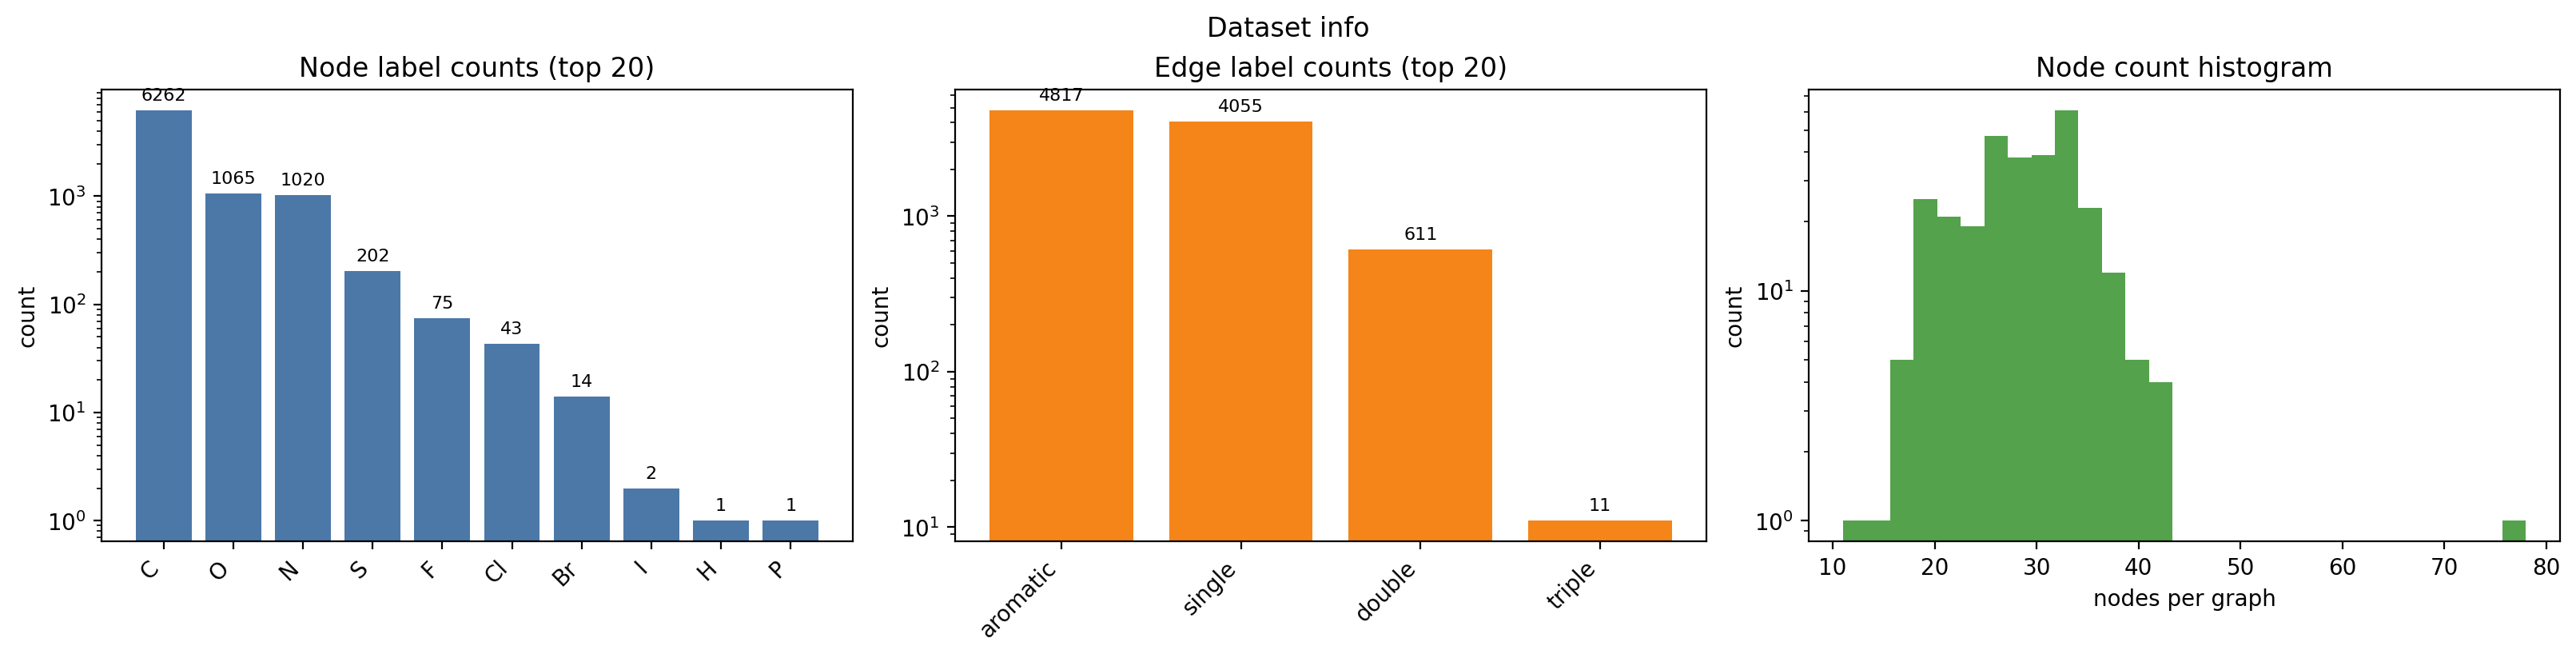

In [4]:
from abstractgraph_graphicalizer.chem import PubChemLoader

loader = PubChemLoader(on_error="skip")

assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213']
assay_id = assay_ids[1]
assay_id = '624249' #bundled-safe assay example
size = int(100/.33) #to account for 0.33 for test and 0.5 for reference
print(f"size: {size}")
use_equalized = True


limit_active = int(size // 2) if use_equalized else int(size)
limit_inactive = int(size // 2) if use_equalized else int(size)
graphs, targets = loader.load(
    assay_id,
    limit_active=limit_active,
    limit_inactive=limit_inactive,
)
targets = np.array(targets)

from abstractgraph.utils import plot_graph_label_counts
_ = plot_graph_label_counts(graphs, top=20, title='Dataset info', log_scale=True)

# Keep downstream notebook cells unchanged
all_graphs = graphs
all_targets = targets
print('dataset size:', len(all_graphs))


Dataset samples


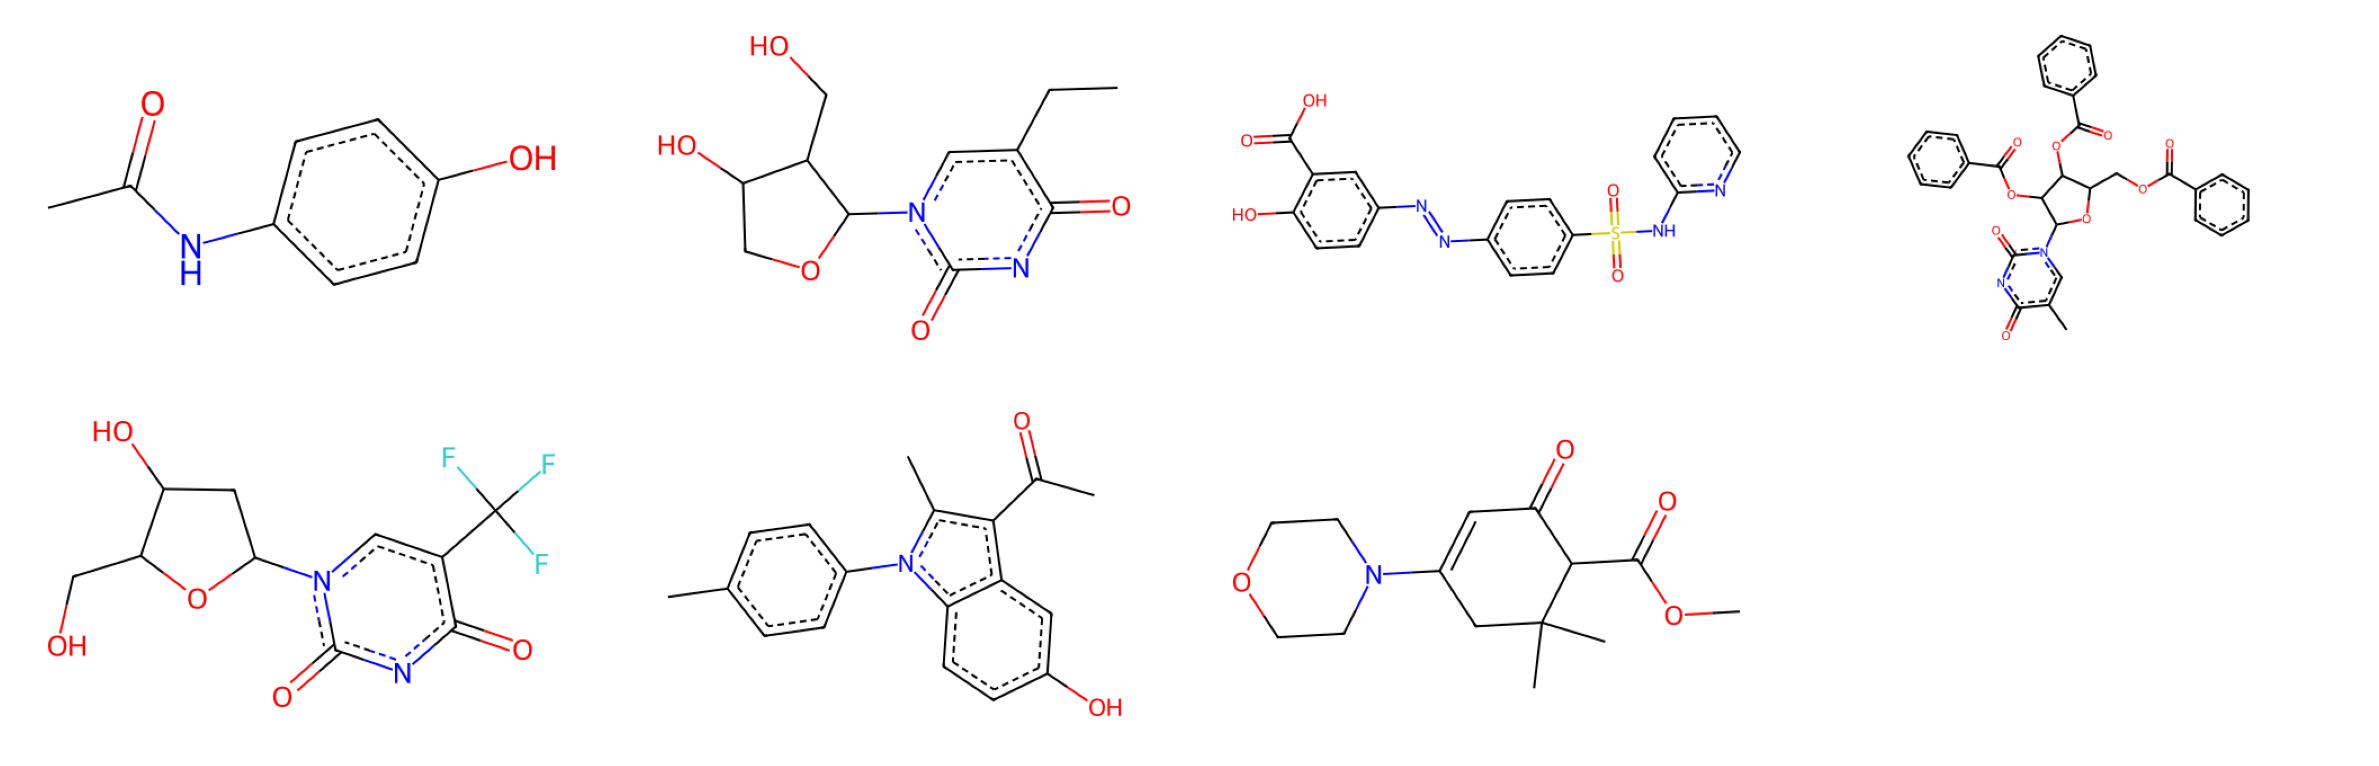

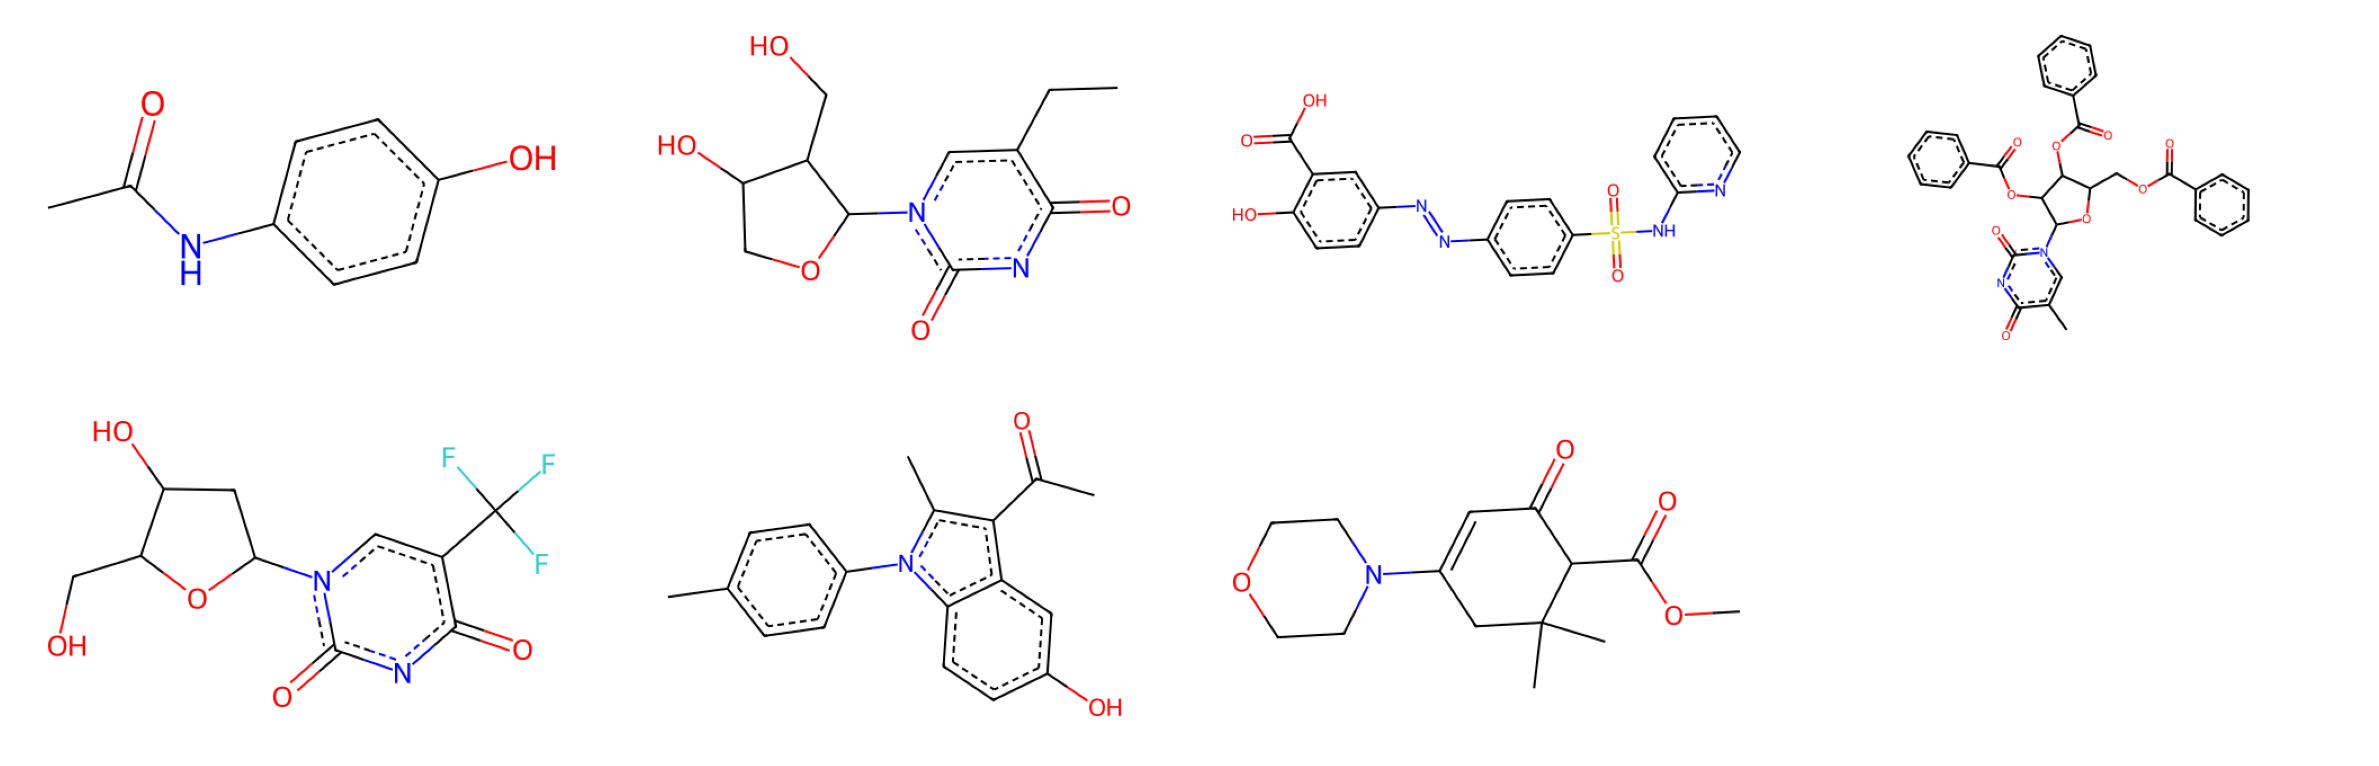

In [5]:
def _fallback_draw_graphs(graphs, cols=4, title='graphs'):
    rows = (len(graphs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.2 * rows))
    axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]
    for i in range(rows * cols):
        ax = axes[i]
        if i < len(graphs):
            g = graphs[i]
            pos = nx.spring_layout(g, seed=1)
            node_labels = nx.get_node_attributes(g, 'label')
            nx.draw(g, pos=pos, ax=ax, with_labels=True, labels=node_labels, node_size=300, font_size=8)
            ax.set_title(f'n={g.number_of_nodes()} e={g.number_of_edges()}', fontsize=9)
        else:
            ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_graphs(graphs, cols=4, title='graphs'):
    if not graphs:
        print('No graphs to display')
        return
    print(title)
    try:
        return display_graphs(graphs)
    except Exception:
        return _fallback_draw_graphs(graphs, cols=cols, title=title)


def show_generation_views(samples, generator_set, mode='nn', cols=7):
    from abstractgraph.hashing import GraphHashDeduper

    _ = show_graphs(
        generator_set,
        cols=cols,
        title=f'Generator set ({mode}) {len(generator_set)} samples',
    )
    novel_samples = GraphHashDeduper().fit(generator_set).filter(samples)
    _ = show_graphs(novel_samples, cols=cols, title=f'Novel {len(novel_samples)} samples')
    unique_samples = GraphHashDeduper().fit_filter(samples)
    _ = show_graphs(unique_samples, cols=cols, title=f'Unique {len(unique_samples)} samples')
    _ = show_graphs(samples, cols=cols, title=f'Generated ({mode}) {len(samples)} samples')
    return novel_samples, unique_samples


show_graphs(all_graphs[:7], cols=4, title='Dataset samples')


## 2) Same generation process helpers (`same_image` / `nn`)

In [6]:
def group_graphs_by_image_hash(graphs, decomposition_function, nbits):
    buckets = {}
    for g in graphs:
        ag = graph_to_abstract_graph(
            g,
            decomposition_function=decomposition_function,
            nbits=nbits,
            label_mode='operator_hash',
        )
        img_hash = hash_graph(ag.interpretation_graph)
        buckets.setdefault(img_hash, []).append(g)
    return buckets


def select_image_group(buckets, min_group_size, rng):
    if not buckets:
        return [], True
    eligible = [grp for grp in buckets.values() if len(grp) >= min_group_size]
    if eligible:
        return rng.choice(eligible), False
    return max(buckets.values(), key=len), True


def select_nn_group(
    graphs,
    seed_graph,
    group_size,
    *,
    radius=1,
    distance=4,
    connector=1,
    nbits=14,
):
    from nsppk import NSPPK
    import scipy.sparse as sp

    graph_list = list(graphs)
    if not graph_list:
        return []

    vectorizer = NSPPK(
        radius=radius,
        distance=distance,
        connector=connector,
        nbits=nbits,
        parallel=True,
    )
    X = vectorizer.fit_transform(graph_list)
    seed_idx = graph_list.index(seed_graph) if seed_graph in graph_list else 0

    if sp.issparse(X):
        seed_row = X[seed_idx]
        numer = X @ seed_row.T
        numer = np.asarray(numer.todense()).ravel() if sp.issparse(numer) else np.asarray(numer).ravel()
        row_norms = np.sqrt(np.asarray(X.multiply(X).sum(axis=1)).ravel())
        seed_norm = float(np.sqrt(seed_row.multiply(seed_row).sum()))
    else:
        Xd = np.asarray(X, dtype=float)
        seed_vec = Xd[seed_idx]
        numer = Xd @ seed_vec
        row_norms = np.linalg.norm(Xd, axis=1)
        seed_norm = float(np.linalg.norm(seed_vec))

    denom = np.maximum(row_norms * max(seed_norm, 1e-12), 1e-12)
    sims = numer / denom
    order = np.argsort(-sims)
    top_idx = order[:group_size]
    return [graph_list[i] for i in top_idx]


def _graph_size_summary(graphs):
    if not graphs:
        return 'empty'
    nodes = [g.number_of_nodes() for g in graphs]
    edges = [g.number_of_edges() for g in graphs]
    return (
        f"nodes(min/mean/max)=({min(nodes)}/{np.mean(nodes):.1f}/{max(nodes)}) "
        f"edges(min/mean/max)=({min(edges)}/{np.mean(edges):.1f}/{max(edges)})"
    )


def _fit_context_vectorizer_if_needed(context_vectorizer, graphs):
    if context_vectorizer is None or not hasattr(context_vectorizer, 'fit'):
        return context_vectorizer
    try:
        context_vectorizer.fit(graphs)
    except TypeError:
        context_vectorizer.fit(graphs, None)
    return context_vectorizer


def generate_graphs(
    graphs,
    *,
    decomposition_function,
    nbits,
    mode='same_image',
    generator_size=7,
    n_samples=7,
    base_cut_radius=0,
    interpretation_cut_radius=1,
    context_vectorizer=None,
    preimage_context_radius=None,
    num_context_rewirings=16,
    generator_class=AttributedConditionalAutoregressiveGenerator,
    fit_context_vectorizer=True,
    random_seed=0,
    feasibility_estimator=None,
    max_backtracks=12000,
    max_attempts_per_sample=48,
    max_total_attempts=None,
    progress_every_attempts=100,
    progress_every_seconds=10.0,
    parallel_queue_factor=4,
    debug=True,
    debug_level=1,
    return_stats=False,
):
    rng = random.Random(random_seed)
    if len(graphs) < generator_size:
        raise ValueError('graphs size must be >= generator_size')

    if debug:
        print('' + '=' * 100)
        print(f'[DEBUG] mode={mode} nbits={nbits} generator_size={generator_size} n_samples={n_samples}')
        print(f'[DEBUG] generator_class={generator_class.__name__}')
        print(f'[DEBUG] debug_level={debug_level}')
        print(f'[DEBUG] progress every attempts={progress_every_attempts} seconds={progress_every_seconds}')
        print(f'[DEBUG] parallel_queue_factor={parallel_queue_factor}')
        print(f'[DEBUG] radii base={base_cut_radius} interpretation={interpretation_cut_radius} preimage_context={preimage_context_radius}')
        print(f'[DEBUG] num_context_rewirings={num_context_rewirings}')
        print(f'[DEBUG] search max_backtracks={max_backtracks} max_attempts_per_sample={max_attempts_per_sample}')

    if mode == 'same_image':
        buckets = group_graphs_by_image_hash(graphs, decomposition_function, nbits)
        if debug:
            bucket_sizes = sorted((len(v) for v in buckets.values()), reverse=True)
            print(f'[DEBUG] image-hash buckets={len(bucket_sizes)} top10={bucket_sizes[:10]}')
        generator_graphs, used_fallback = select_image_group(buckets, generator_size, rng)
        if used_fallback:
            print('[DEBUG] same_image fallback: largest image-hash bucket used')
        if len(generator_graphs) > generator_size:
            rng.shuffle(generator_graphs)
            generator_graphs = generator_graphs[:generator_size]
    elif mode == 'nn':
        seed_graph = rng.choice(graphs)
        if debug:
            print(f'[DEBUG] nn seed graph: nodes={seed_graph.number_of_nodes()} edges={seed_graph.number_of_edges()}')
        generator_graphs = select_nn_group(graphs, seed_graph, generator_size)
    else:
        raise ValueError("mode must be one of {'same_image', 'nn'}")

    if debug:
        print(f'[DEBUG] generator set size={len(generator_graphs)}')
        print(f'[DEBUG] generator set stats: {_graph_size_summary(generator_graphs)}')

    if fit_context_vectorizer:
        context_vectorizer = _fit_context_vectorizer_if_needed(context_vectorizer, generator_graphs)

    generator = generator_class(
        decomposition_function=decomposition_function,
        nbits=nbits,
        feasibility_estimator=feasibility_estimator,
        base_cut_radius=base_cut_radius,
        interpretation_cut_radius=interpretation_cut_radius,
        context_vectorizer=context_vectorizer,
        preimage_context_radius=preimage_context_radius,
        num_context_rewirings=num_context_rewirings,
        n_jobs=-1,
        debug=debug,
        debug_level=debug_level,
    )

    t0 = time.time()
    generator.fit(generator_graphs)
    fit_s = time.time() - t0

    t1 = time.time()
    strict_samples = generator.generate(
        n_samples=n_samples,
        random_state=random_seed,
        max_backtracks=max_backtracks,
        max_attempts_per_sample=max_attempts_per_sample,
        max_total_attempts=max_total_attempts,
        progress_every_attempts=progress_every_attempts,
        progress_every_seconds=progress_every_seconds,
        parallel_queue_factor=parallel_queue_factor,
    )
    gen_s = time.time() - t1

    samples = strict_samples
    strict_count = len(strict_samples)

    print(f'mode={mode} generator_set={len(generator_graphs)} fit={fit_s:.2f}s generate={gen_s:.2f}s out={strict_count}')

    if debug:
        print(f'[DEBUG] strict output stats: {_graph_size_summary(strict_samples)}')

    if return_stats:
        stats = {
            'strict_generated': strict_count,
            'final_generated': len(samples),
            'relaxed_used': False,
            'generator_set_size': len(generator_graphs),
            'fit_seconds': fit_s,
            'generate_seconds': gen_s,
            'base_cut_radius': base_cut_radius,
            'interpretation_cut_radius': interpretation_cut_radius,
            'preimage_context_radius': preimage_context_radius,
            'num_context_rewirings': num_context_rewirings,
            'generator_class': generator_class.__name__,
            'mode': mode,
        }
        return samples, generator_graphs, stats

    return samples, generator_graphs


---

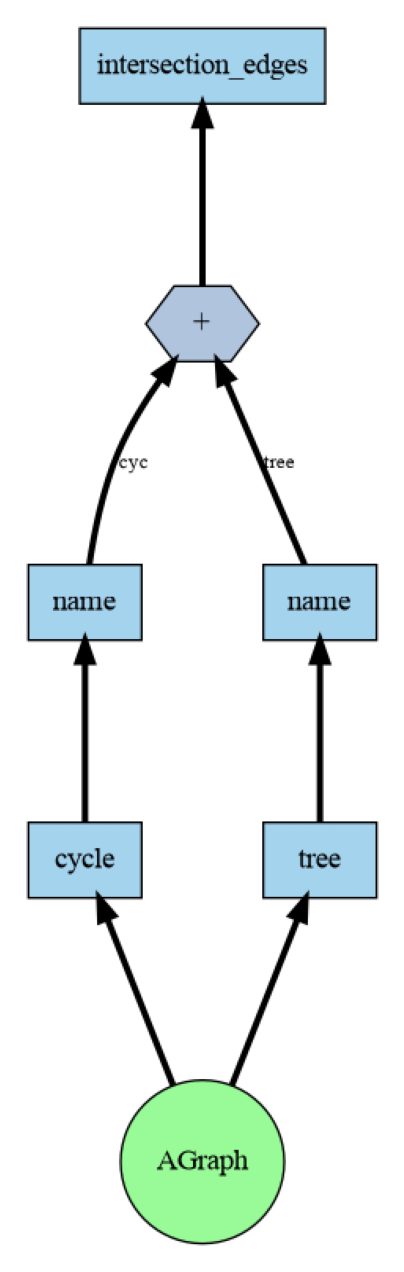

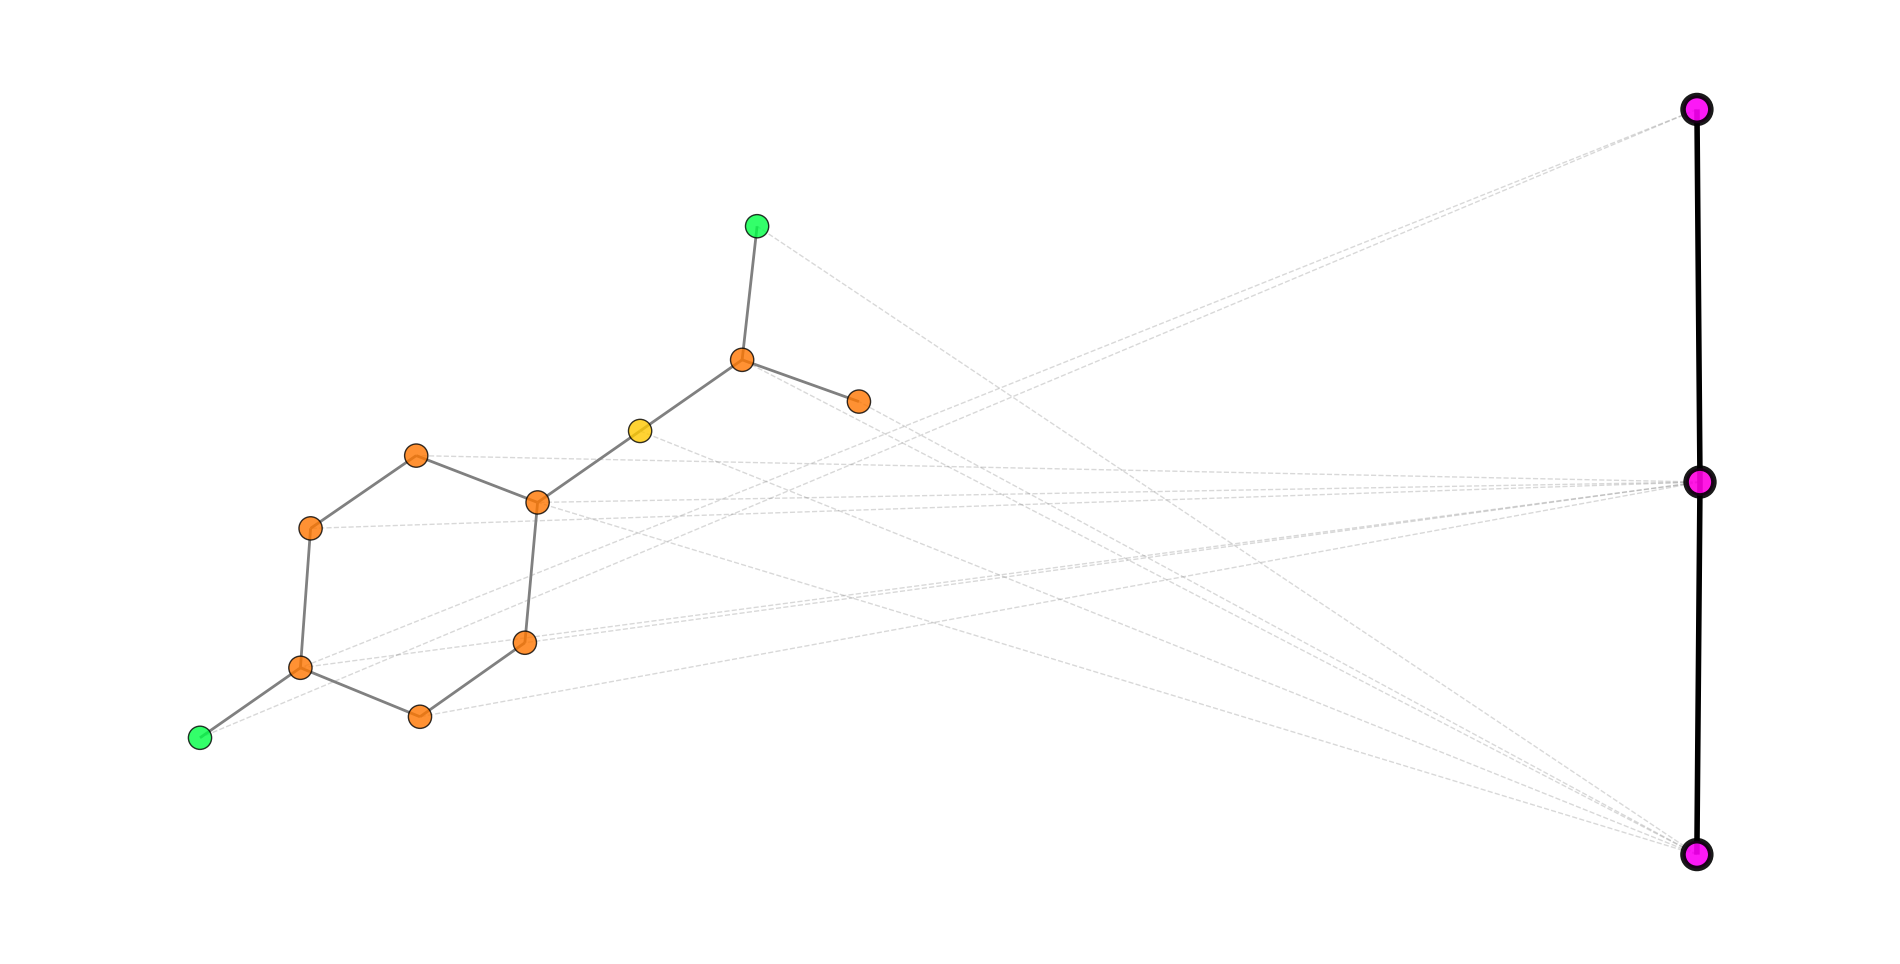

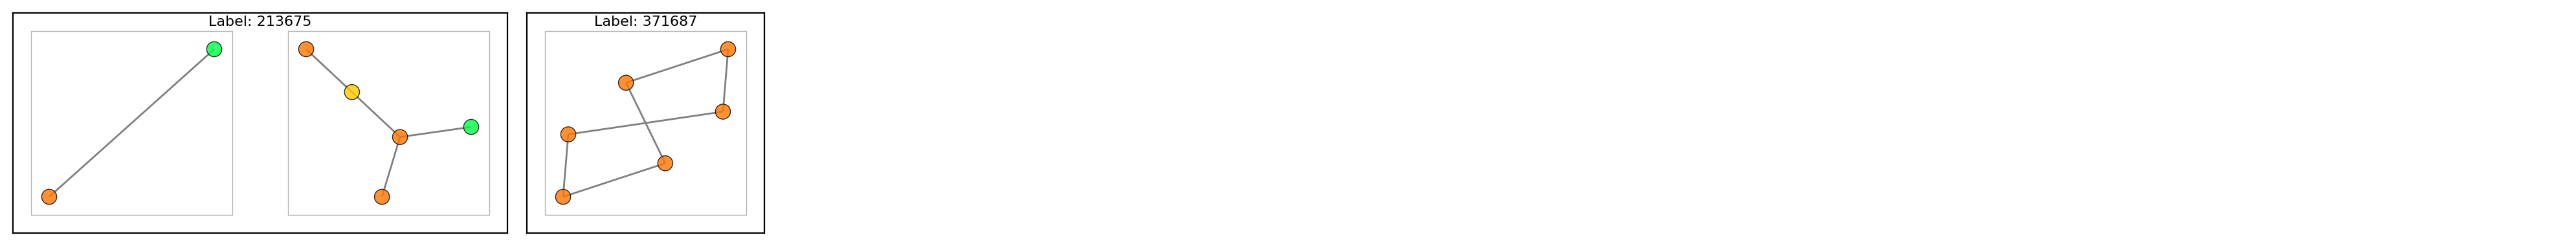

In [7]:
from abstractgraph.operators import *


#core_df = compose(name('cor'),betweenness_centrality_hop_split(n_hops=1), split(n_parts=3))
core_df = compose(name('cor'), split(n_parts=3))
connector_df = compose(name('con'), connected_component(), edge_complement(), merge(use_edges=True), core_df)
decomposition_function = compose(intersection_edges(), remove_redundant_associations(), add(connector_df, core_df))


df = add(compose(name('cyc'), cycle()), compose(name('tree'), tree()))
decomposition_function = compose(intersection_edges(), df)

nbits = 19

from abstractgraph_ml.feasibility import FeasibilityEstimatorFeatureCannotExist, FeasibilityEstimator, WithinRangeFeasibilityEstimatorFromNumericalFunction
from abstractgraph.operators import *
fe0 = WithinRangeFeasibilityEstimatorFromNumericalFunction(numerical_function=lambda graph: len(graph), quantile=None)
df = compose(neighborhood(radius=2), unlabel())
fe1 = FeasibilityEstimatorFeatureCannotExist(decomposition_function=df, nbits=19, parallel=True, backend="dill")
df = neighborhood(radius=1)
fe2 = FeasibilityEstimatorFeatureCannotExist(decomposition_function=df, nbits=19, parallel=True, backend="dill")
df = cycle()
fe3 = FeasibilityEstimatorFeatureCannotExist(decomposition_function=df, nbits=19, parallel=True, backend="dill")
feasibility_estimators = [fe0, fe1, fe2, fe3]
feasibility_estimator = FeasibilityEstimator(feasibility_estimators)

#feasibility_estimator= None
draw(all_graphs[0], decomposition_function, nbits)

In [ ]:
%%time
from nsppk import NSPPK

context_vectorizer = NSPPK(
    radius=1,
    distance=3,
    connector=1,
    nbits=nbits,
    parallel=True,
)

nn_samples, nn_generator_set, nn_stats = generate_graphs(
    all_graphs,  # full candidate training pool
    decomposition_function=decomposition_function,  # graph -> AbstractGraph decomposition pipeline
    nbits=nbits,  # hash width used by image-labeling/indexing
    mode='nn',  # build generator set from nearest neighbors of one seed graph
    generator_size=7,  # number of graphs used to fit this generator
    n_samples=50,  # number of feasible samples requested
    base_cut_radius=0,  # anchor context radius in base-graph matching
    interpretation_cut_radius=1,  # neighborhood radius for interpretation-node signature buckets
    context_vectorizer=context_vectorizer,  # graph vectorizer used for attributed context scoring
    preimage_context_radius=None,  # radius for the union of anchor neighborhoods
    num_context_rewirings=8,  # number of legal rewiring branches scored per step
    generator_class=AttributedConditionalAutoregressiveGenerator,
    random_seed=1,  # sampling/reproducibility seed (None -> non-deterministic)
    feasibility_estimator=feasibility_estimator,  # final-graph feasibility filter
    max_backtracks=12000,  # branch limit per sample search
    max_attempts_per_sample=48,  # retry budget multiplier used in total-attempt cap
    debug=True,  # enable generator debug logging
    debug_level=1,  # summary-level logs (2 = per-attempt/per-node verbose)
    progress_every_attempts=1000,  # heartbeat log cadence by submitted attempts
    progress_every_seconds=30.0,  # heartbeat log cadence by elapsed time
    parallel_queue_factor=12,  # in-flight futures per worker (higher => better CPU saturation)
    return_stats=True,
)

print(nn_stats)

novel_samples, unique_samples = show_generation_views(
    samples=nn_samples,
    generator_set=nn_generator_set,
    mode='nn-attributed',
    cols=7,
)


[DEBUG] mode=nn nbits=19 generator_size=7 n_samples=50
[DEBUG] generator_class=AttributedConditionalAutoregressiveGenerator
[DEBUG] debug_level=1
[DEBUG] progress every attempts=1000 seconds=30.0
[DEBUG] parallel_queue_factor=12
[DEBUG] radii base=0 interpretation=1 preimage_context=None
[DEBUG] num_context_rewirings=8
[DEBUG] search max_backtracks=12000 max_attempts_per_sample=48
[DEBUG] nn seed graph: nodes=32 edges=35
[DEBUG] generator set size=7
[DEBUG] generator set stats: nodes(min/mean/max)=(26/31.1/37) edges(min/mean/max)=(29/34.1/41)
[DEBUG] event=fit_dictionaries
[DEBUG]   bucket_keys=8
[DEBUG]   components=64
[DEBUG]   image_pool=7
[DEBUG]   inv_freq_keys=14
[DEBUG]   inv_keys=14
[DEBUG]   skipped_missing_anchor_components=0
[DEBUG] event=fit_distributions_index
[DEBUG]   bucket_size=min/mean/max=(1/8.00/25)
[DEBUG]   inv_members=min/mean/max=(1/5.64/24)
[DEBUG] event=fit_distributions_components
[DEBUG]   anchors_per_port=min/mean/max=(1/1.12/2)
[DEBUG]   component_degree=m